In [1]:
from _HyperSBM import *
from _HyperCommunityDetection import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.special import comb
from _CommunityDetect import *
from spectralOperator import BetheHessian
# from EXPERIMENT_2orderHYPERGRAPH import *
from EXPERIMENT_HYPER import *
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams["mathtext.fontset"] = 'cm'

%config InlineBackend.figure_format = 'retina'

# Uniform

In [3]:
n = 30000
q = 2
d = 10
Ks = (3, )
addtionTag = ""
bp = False
fileId = 'amiExpHyper24.12.20' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'  # 0.1-1  20 times
load_path = "./result/detectabilityHyper/" + fileId + ".txt"

addtionTag = "0.4-0.5"
add_fileId = 'amiExpHyper24.12.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}' # 0.4-0.5  20 times
addtionTag = "0.4-0.5more30"
add_fileId1 = 'amiExpHyper24.12.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}' # 0.4-0.5  30 times
addtionTag = "more30"
add_fileId2 = 'amiExpHyper24.12.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}' # 0.1-1  30 times
add_paths = ["./result/detectabilityHyper/" + fid + ".txt" for fid in [add_fileId, add_fileId1, add_fileId2]]
epsilons, results = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...


In [4]:
e = (np.sqrt(d * (Ks[0] - 1)) - 1) / (np.sqrt(d * (Ks[0] - 1)) + q - 1)
crit_epsilon = e / (q**(Ks[0] - 2) - (q**(Ks[0] - 2) - 1) * e)
print(crit_epsilon)

0.4646778345456075


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):
C:\Users\24391\AppData\Local\Temp\ipykernel_13052\4156031222.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  axins.set_yticklabels([0, 0.1, 0.2], fontsize=12)


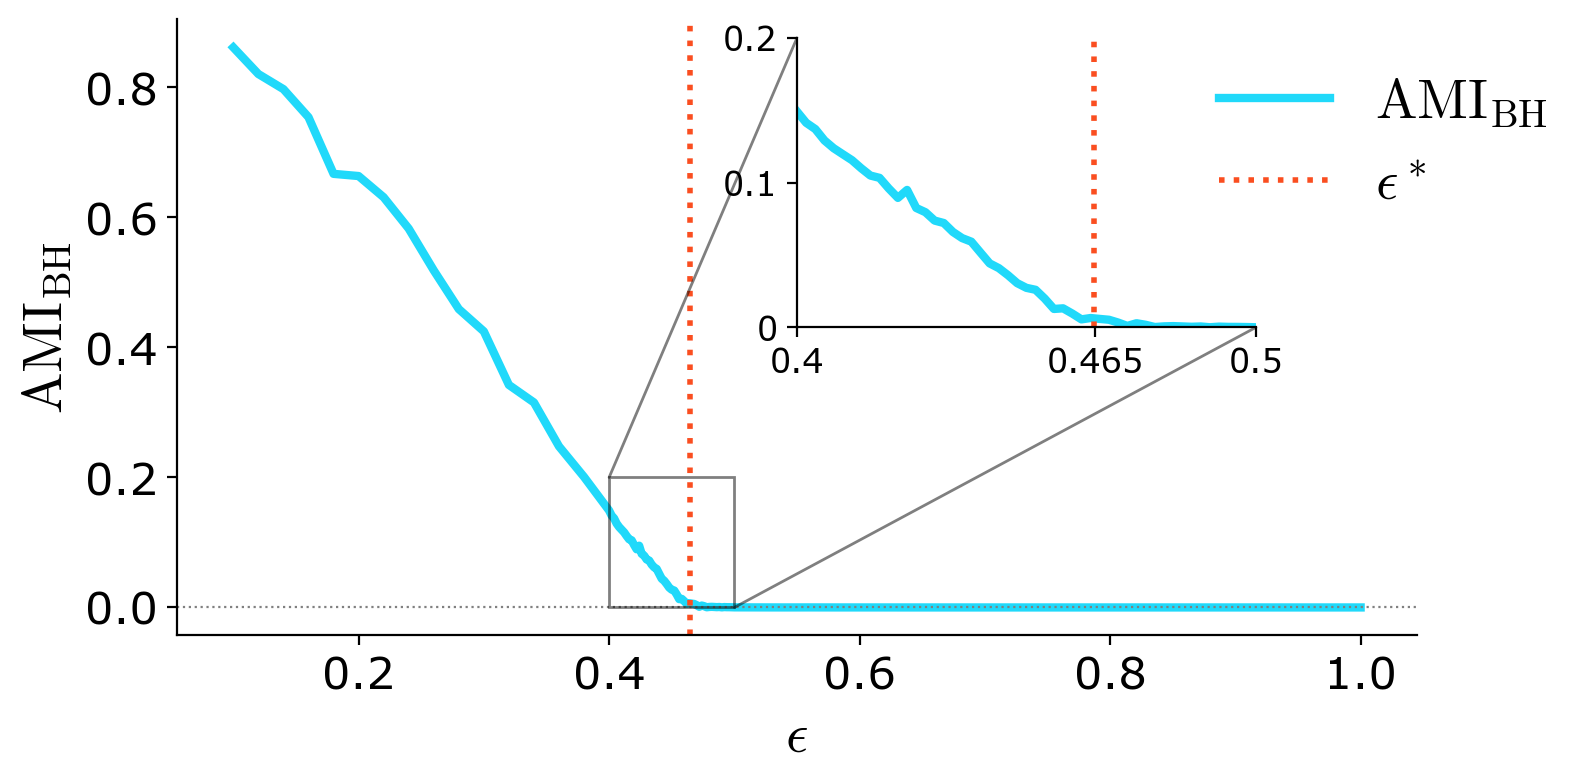

In [5]:
fig = plt.figure(figsize=(8, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
bhami_color = "#20D9FA"
ax.plot(epsilons, results[0], lw=3, c=bhami_color, label=r'$\rm AMI_{BH}$')
# # plt.axvline(1, color='k', lw=1)
# # plt.axvline(crit_epsilon, color='red', lw=0.8, ls=':')
plt.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel(r"$\epsilon$", fontsize=20)
ax.set_ylabel(r"$\rm AMI_{BH}$", fontsize=20)
phi_color = '#FA4E20'
ax.axvline(crit_epsilon, color=phi_color, lw=2, ls=':', label=r'$\epsilon^*$')
plt.legend(loc=2, bbox_to_anchor=(0.8, 0.99), fontsize=20, markerscale=2, frameon=False)
# plt.title(f'Nonuniform case n={n} q={q} d={d} Ks={Ks}')

# subregion zoom
x1, x2, y1, y2 = 0.4, 0.5, 0, 0.2  # subregion of the original image
axins = ax.inset_axes(
    [0.5, 0.5, 0.37, 0.47],
    xlim=(x1, x2), ylim=(y1, y2), xticks=[0.4, 0.465, 0.5])
axins.set_xticklabels([0.4, 0.465, 0.5], fontsize=12)
axins.set_yticklabels([0, 0.1, 0.2], fontsize=12)
sub_points_x = []
sub_points_y = []
for i, epsilon in enumerate(epsilons):
    if 0.4 <= epsilon <= 0.5:
        sub_points_x.append(epsilon)
        sub_points_y.append(results[0][i])
axins.plot(sub_points_x, sub_points_y, lw=3, c=bhami_color, label=r'\rm AMI_{BH}')
# axins.axhline(0, color='grey', lw=1, ls=':')
axins.axvline(crit_epsilon, color=phi_color, lw=2, ls=':', label=r'$\epsilon}^*$')

ax.indicate_inset_zoom(axins, edgecolor="black")
save_path = "./_Figure/Hyper/Detectability/" + "UniformHyper_AMI_epsilon_BH_v2.pdf"
plt.savefig(save_path, dpi=600, bbox_inches='tight')

# NonUniform

In [3]:
def get_phi(n, q, Ks, d, epsilons):
    phi_1s = []
    phi_2s = []
    for e in epsilons:
        temp = 0
        for k in Ks:
            temp += q * comb(int(n/q), k) * k / (n**k) + e * (comb(n, k) - q * comb(int(n/q), k)) * k / (n**k)
        cin = d / temp
        cout = e * cin
        alphas = dict()
        betas = dict()
        for k in Ks:
            c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
            c_kout = cout / np.math.factorial(k - 2)
            alphas[k] = (c_kin + (q-1) * c_kout) / q
            betas[k] = (c_kin - c_kout) / q
        phi_1 = np.sum([betas[k] for k in betas.keys()]) ** 2 / np.sum([alphas[k] for k in alphas.keys()])
        phi_2 = np.sum([betas[k]**2/alphas[k] for k in Ks])
        phi_1s.append(phi_1)
        phi_2s.append(phi_2)
#     print(phi_1s)
#     print(phi_2s)
    return phi_1s, phi_2s

In [4]:
# Our detectability
def get_piepsilonk(q, e, k):
    return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))

def get_snr(n, q, Ks, d, epsilons):
    snrs = []
    for e in epsilons:
        Zk = 0
        sumpi = 0
        sumkminus1pi = 0
        sumkpi = 0
        for k in Ks:
            pi_epsilonk = get_piepsilonk(q, e, k)
            Zk += pi_epsilonk
            sumpi += pi_epsilonk
            sumkminus1pi += (k-1)*pi_epsilonk
            sumkpi += k * pi_epsilonk
        prod = 1
        ci = d / sumkpi
        for k in Ks:
            pi_epsilonk = get_piepsilonk(q, e, k)
            prod *= (1/(q**k*np.math.factorial(k)*pi_epsilonk*ci))**(pi_epsilonk/Zk)
        current_snr = q*(1-e)*ci*np.sqrt(d*sumkminus1pi/sumpi)*prod
        snrs.append(current_snr)
    return snrs

In [24]:
def plot_ami(bh_epsilons, bh_results, bh_std, bp_epsilons, bp_results, bp_std, n, q, d, Ks, 
             label1=r'$\rm AMI_{BH}$', label2=r'$\rm AMI_{BP}$', 
             c1="#20D9FA", c2="#A4FA83"):
    fig = plt.figure(figsize=(8, 4))
    widths = [4]
    heights = [4]
    spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    ax.plot(bh_epsilons, bh_results[0], lw=3, c=c1, label=label1)
    ax.fill_between(bh_epsilons, bh_results[0]-bh_std, bh_results[0]+bh_std ,alpha=0.3, facecolor=c1)
    ax.plot(bp_epsilons, bp_results[0], lw=3, c=c2, label=label2)
    ax.fill_between(bp_epsilons, bp_results[0]-bp_std, bp_results[0]+bp_std ,alpha=0.3, facecolor=c2)
    # # plt.axvline(1, color='k', lw=1)
    # # plt.axvline(crit_epsilon, color='red', lw=0.8, ls=':')
    plt.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel(r"$\epsilon$", fontsize=20)
    ax.set_ylabel(r"$\rm AMI$", fontsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.legend(loc=2, bbox_to_anchor=(0.6, 1),  fontsize=20, markerscale=2, frameon=False)
    
    ax_twin = ax.twinx()
    phi_number = 1000
    min_epsilon = min(np.min(bh_epsilons), np.min(bp_epsilons))
    max_epsilon = max(np.max(bh_epsilons), np.max(bp_epsilons))
    phi_epsilons = np.linspace(min_epsilon, max_epsilon, phi_number)
    ones = np.array([1]*phi_number)
    phi_1s, phi_2s = get_phi(n, q, Ks, d, phi_epsilons)
    snrs = get_snr(n, q, Ks, d, phi_epsilons)
    idx_1 = np.argwhere(np.diff(np.sign(phi_1s - ones))).flatten() # cross point
    idx_2 = np.argwhere(np.diff(np.sign(phi_2s - ones))).flatten() # cross point
    idx_3 = np.argwhere(np.diff(np.sign(snrs - ones))).flatten() # cross point
    # ax_twin.axhline(1, color='gray', lw=0.8)
    # ax_twin.plot(phi_epsilons, phi_1s, linewidth=0.5, c='#FAAD20', alpha=0.5, label=r'$\phi$')
    # ax_twin.plot(phi_epsilons, phi_2s, linewidth=1, c='red', label=r'$\phi_2$')
    # ax_twin.plot(phi_epsilons, snrs, linewidth=0.5, c='#FA4E20', alpha=0.5, label=r'$\rm snr$')
    ax_twin.axvline(phi_epsilons[idx_1], color='#FAAD20', lw=2, ls='-.', label=r'$\epsilon_{\rm BH}^*$')
    # ax_twin.axvline(phi_epsilons[idx_2], color='red', lw=0.8, ls=':', label=r'$\epsilon_2^*$')
    ax_twin.axvline(phi_epsilons[idx_3], color='#FA4E20', lw=2, ls=':', label=r'$\epsilon_{\rm BP}^*$')
    # ax_twin.set_ylabel(r'$\phi\ or\ \mathrm{snr}$')
    ax_twin.set_yticks([])
    
    plt.legend(loc=2, bbox_to_anchor=(0.6,0.6),  fontsize=20, markerscale=2, frameon=False)
    return ax
    # plt.title(f'Detectability for n={n} q={q} d={d} Ks={Ks}')

In [31]:
n = 30000
q = 2
d = 10
Ks = (2, 3)
addtionTag = "0.4~0.6"
fileId = 'amiExpHyper24.11.1' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 5 times
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
addtionTag = "0.4~0.6more5"
add_fileId = 'amiExpHyper24.11.1' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 5 times
addtionTag = "0.4~0.6more10"
add_fileId1 = 'amiExpHyper24.11.7' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 10 times
addtionTag = "0.4~0.6more30"
add_fileId2 = 'amiExpHyper24.12.22' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 30 times
addtionTag = "0.4~0.6more50"
add_fileId3 = 'amiExpHyper24.12.24' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 50 times
add_paths = ["./result/detectabilityHyper/" + fid + ".txt" for fid in [add_fileId, add_fileId1, add_fileId2, add_fileId3]]
# add_paths = []
bh_epsilons, bh_results, bh_stdresults = read_exp(load_path=load_path, add_paths=add_paths)

bp = True
addtionTag = "0.4-0.6"
fileId = 'amiExpHyper24.12.12' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'  # 2 times
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
addtionTag = "0.4-0.6more3"
add_fileId = 'amiExpHyper24.12.16' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'  # 3 times
addtionTag = "0.4-0.6more5"
add_fileId1 = 'amiExpHyper24.12.25' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'  # 5 times
add_paths = ["./result/detectabilityHyper/" + fid + ".txt" for fid in [add_fileId, add_fileId1, ]]
# add_paths = []
bp_epsilons, bp_results, bp_stdresults = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...
Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` modu

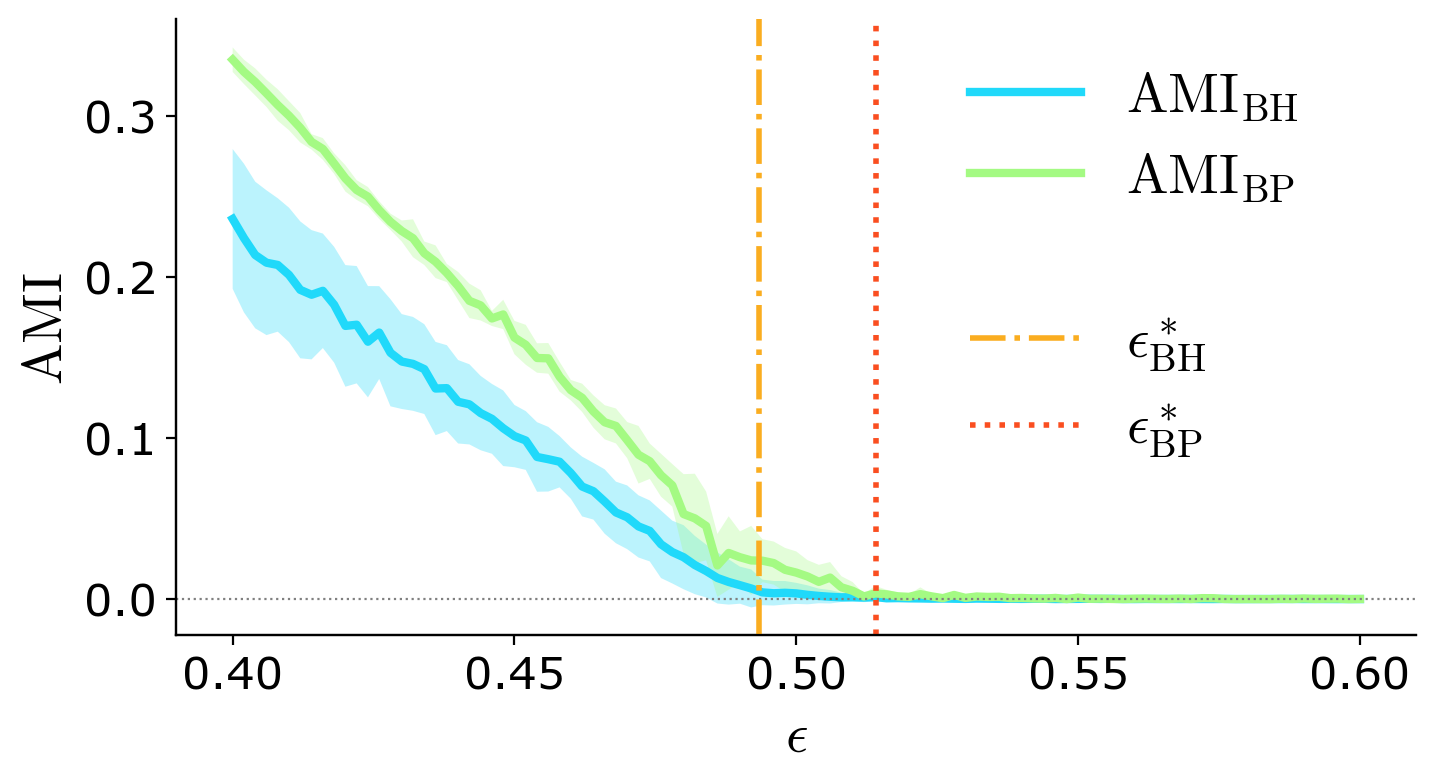

In [33]:
plot_ami(bh_epsilons, bh_results, bh_stdresults[0], bp_epsilons, bp_results, bp_stdresults[0], n, q, d, Ks)
save_path = f"./_Figure/Hyper/Detectability/" + f"NonuniformHyper_AMI_epsilon_BHBP_q={q}_v3.pdf"
plt.savefig(save_path, dpi=600, bbox_inches='tight')

In [34]:
n = 30000
q = 3
d = 10
Ks = (2, 3)
addtionTag = "0.3~0.5"
fileId = 'amiExpHyper24.11.12' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 5 times
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
addtionTag = "0.3~0.5more5"
add_fileId = 'amiExpHyper24.11.15' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 5 times
addtionTag = "0.3~0.5more40"
add_fileId1 = 'amiExpHyper24.12.23' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 40 times
addtionTag = "0.3~0.5more50"
add_fileId2 = 'amiExpHyper24.12.24' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}BH{addtionTag}'  # 50 times
add_paths = ["./result/detectabilityHyper/" + fid + ".txt" for fid in [add_fileId, add_fileId1, add_fileId2]]
# add_paths = []
bh_epsilons, bh_results, bh_stdresults = read_exp(load_path=load_path, add_paths=add_paths)

bp = True
addtionTag = "0.3-0.5"
fileId = 'amiExpHyper24.12.20' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'  # 2 times
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
addtionTag = "0.3-0.5more3"
add_fileId = 'amiExpHyper25.1.7' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'  # 3 times
add_paths = ["./result/detectabilityHyper/" + fid + ".txt" for fid in [add_fileId, ]]
# add_paths = []
bp_epsilons, bp_results, bp_stdresults = read_exp(load_path=load_path, add_paths=add_paths)

scLaplacian = True
fileId = 'amiExpHyper26.04.01' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_SCLaplacian_'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
sclap_epsilons, sclap_results, sclap_stdresults = read_exp(load_path=load_path, add_paths=[])

Additional result adding...
Additional result adding...
Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` modu

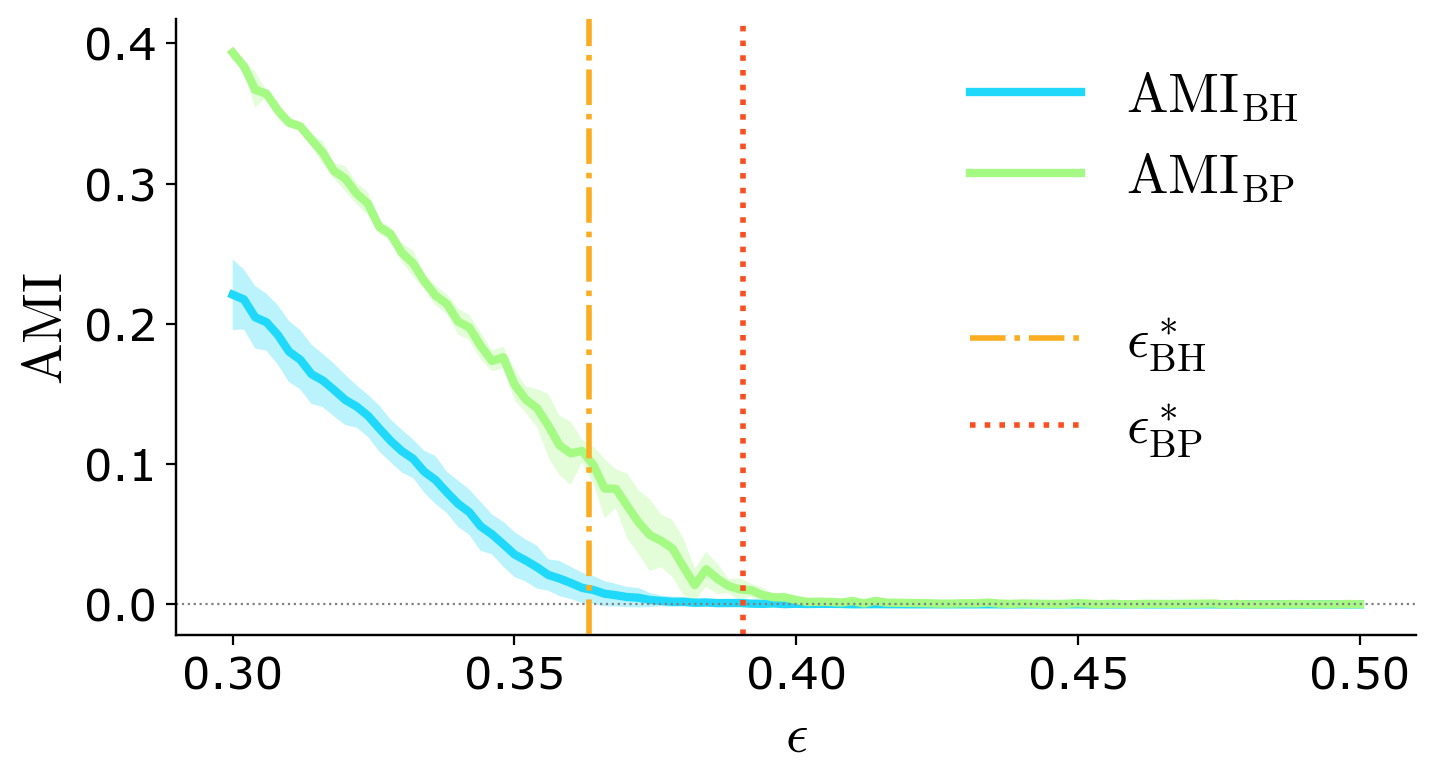

In [35]:
plot_ami(bh_epsilons, bh_results, bh_stdresults[0], bp_epsilons, bp_results, bp_stdresults[0], n, q, d, Ks)
# save_path = f"./_Figure/Hyper/Detectability/" + f"NonuniformHyper_AMI_epsilon_BHBP_q={q}.pdf"
save_path = f"./_Figure/Hyper/Detectability/" + f"NonuniformHyper_AMI_epsilon_BHBP_q={q}_v3.pdf"
plt.savefig(save_path, dpi=600, bbox_inches='tight')

C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` modu

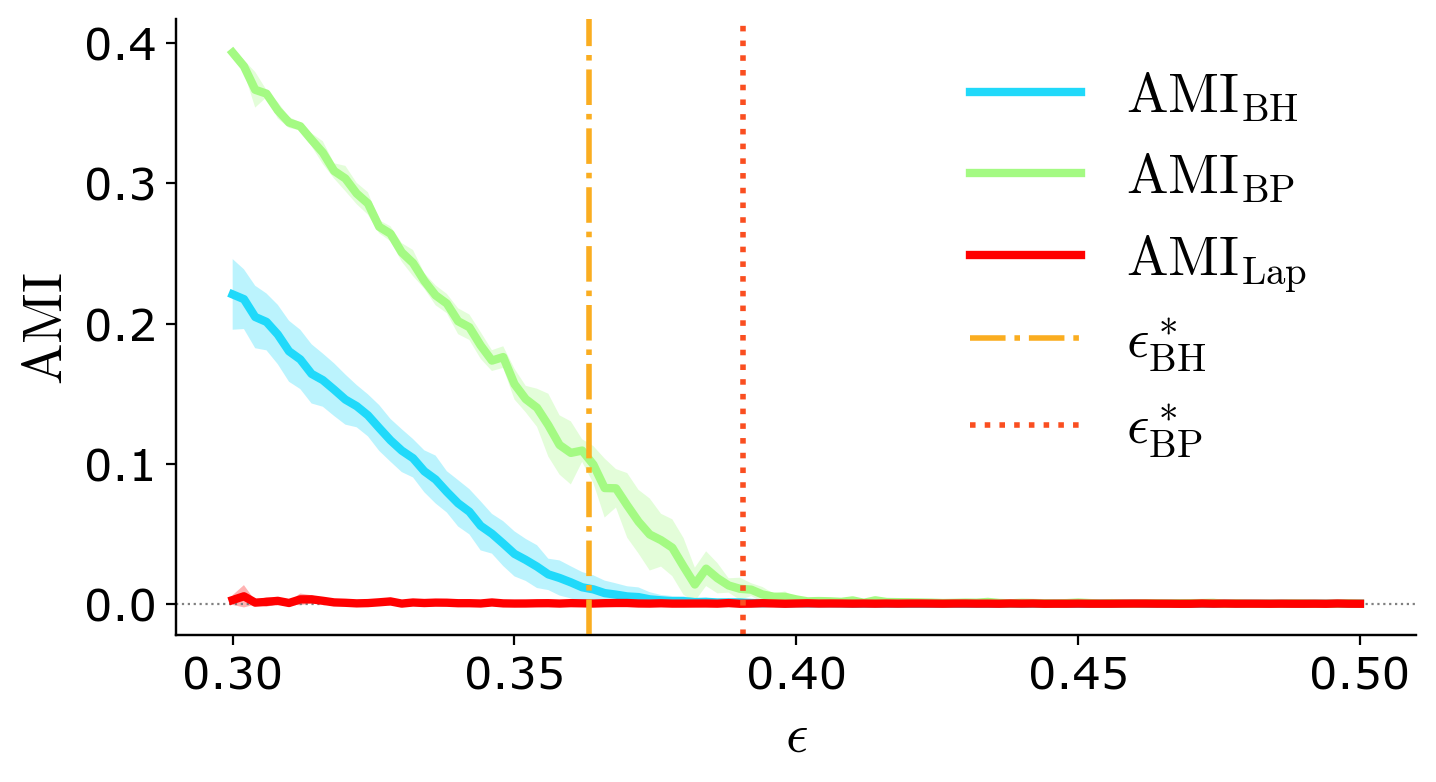

In [36]:
ax = plot_ami(bh_epsilons, bh_results, bh_stdresults[0], bp_epsilons, bp_results, bp_stdresults[0], n, q, d, Ks)
ax.plot(sclap_epsilons, sclap_results[0], lw=3, c="red", label=r'$\rm AMI_{Lap}$')
ax.fill_between(sclap_epsilons, sclap_results[0]-sclap_stdresults[0], sclap_results[0]+sclap_stdresults[0], alpha=0.3, facecolor="red")
ax.legend(loc=2, bbox_to_anchor=(0.6, 1),  fontsize=20, markerscale=2, frameon=False)

# Minority

In [7]:
from EXPERIMENT_Minority_HyperBH import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from _FigureJiazeHelper import *

%load_ext autoreload
%autoreload 2

In [11]:
# For big n
fix_parameter = {
        "n": 5000,
        "q_s": 2,
        "q_b": 2,
        "q": 4,
        "d": 10,
        "times": 10,
        "Ks": (2, 3),
    }
addtionTag = ""
fileId = 'amiExpMinorityHyperBH25.12.26' + f'_n={fix_parameter["n"]}_q={fix_parameter["q"]}_d={round(fix_parameter["d"])}_Ks={fix_parameter["Ks"]}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
plot_rhos, plot_zs, ami, num_group = read_exp(load_path=load_path)
print(np.unique(plot_rhos))

[0.01   0.0296 0.0492 0.0688 0.0884 0.108  0.1276 0.1472 0.1668 0.1864
 0.206  0.2256 0.2452 0.2648 0.2844 0.304  0.3236 0.3432 0.3628 0.3824
 0.402  0.4216 0.4412 0.4608 0.4804 0.5   ]


setting xticks
minz=4.5, maxz=4.5, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['4', '2', '2', '4']
setting xticks
minz=-0.00013099999999999999, maxz=0.8471649999999998, cticks=[0.        0.0154114 0.0308228 0.0462342], clabel=['0', '0', '0', '0']


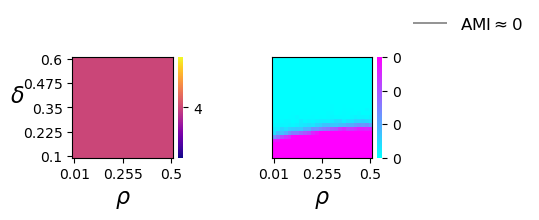

In [ ]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, ami, z_center=zcenter, title="", xlabel=r'$\rho$', 
                              ylabel=r'$\epsilon$', cmap=cmap, ax=ax, fig=fig,  ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
lgd = fig.legend(handels, [r'AMI$\approx$0', r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.subplots_adjust(wspace=0.8)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# More Baselines

In [26]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
addtionTag = ""
fileId = 'amiExpHyper26.03.20' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_SCLaplacian_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
# add_file1 = 'amiExpHyper26.03.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_SCLaplacian_0.4~0.6more10'
# add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
laplacian_epsilons, laplacian_results, laplacian_varresults = read_exp(load_path=load_path, add_paths=[])

Additional result adding...


In [27]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
addtionTag = ""
fileId = 'amiExpHyper26.03.16' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_Louvain_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
# add_file1 = 'amiExpHyper26.03.20' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_Louvain_0.4~0.6more10'
# add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
louvain_epsilons, louvain_results, louvain_vartrsults = read_exp(load_path=load_path, add_paths=[])

Additional result adding...


In [28]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
bp = False
addtionTag = ""
# fileId = 'amiExpHyper26.03.18' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BH_{addtionTag}'
givenNumGroup = q
fileId = 'amiExpHyper26.03.24' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BH_givenNumGroup={givenNumGroup}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
# add_file1 = 'amiExpHyper26.03.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BH_0.4~0.6more10'
# add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
add_paths = []
hbh_epsilons, hbh_results, hbh_varresults = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_2136\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` modu

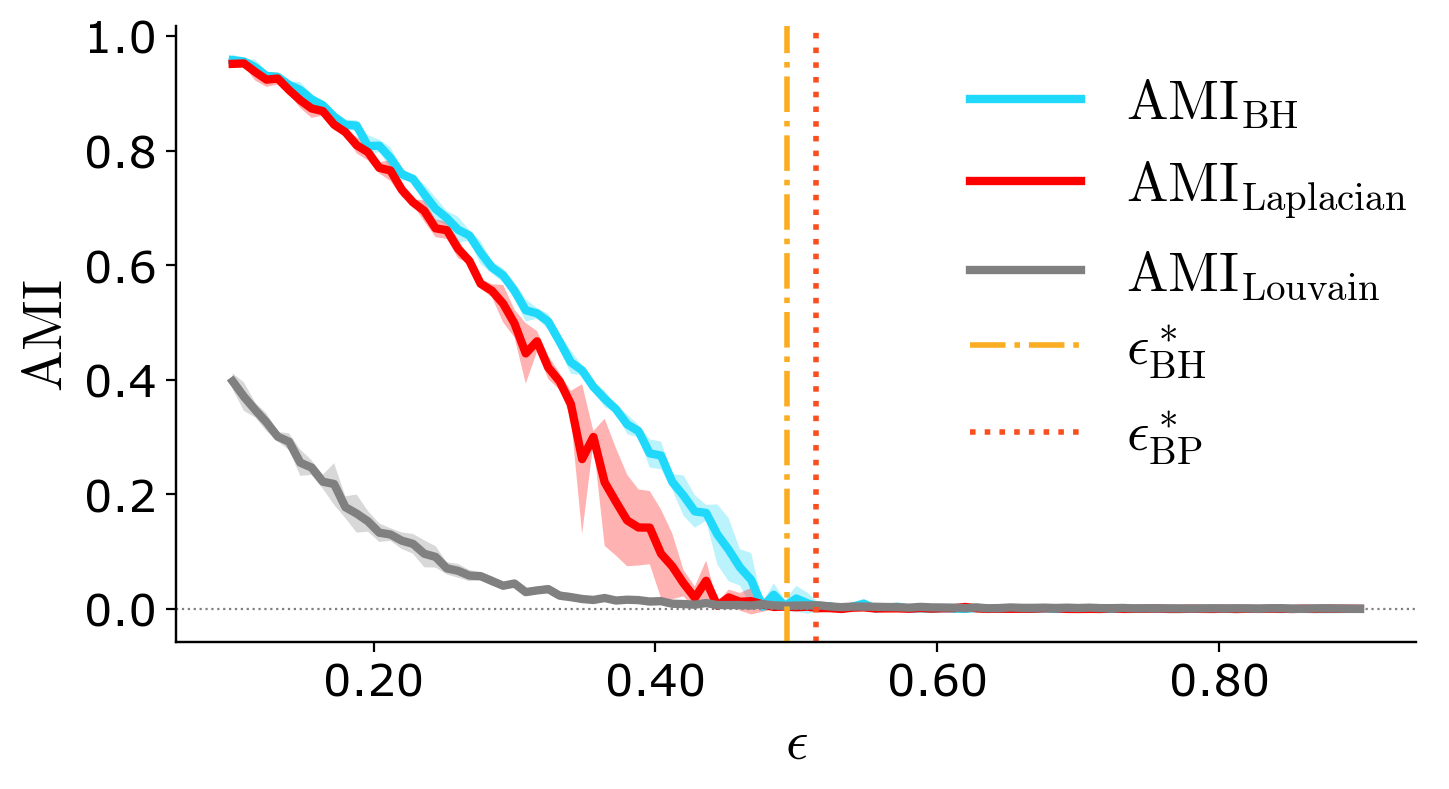

In [30]:
ax = plot_ami(hbh_epsilons, hbh_results, hbh_varresults[0],
              laplacian_epsilons, laplacian_results, laplacian_varresults[0],
              n, q, d, Ks, 
              label1=r"$\rm AMI_{BH}$", label2=r"$\rm AMI_{Laplacian}$",
              c1="#20D9FA", c2="red")
ax.plot(louvain_epsilons, louvain_results[0], lw=3, c="gray", label=r'$\rm AMI_{Louvain}$')
ax.fill_between(louvain_epsilons, louvain_results[0]-louvain_vartrsults[0], louvain_results[0]+louvain_vartrsults[0], alpha=0.3, facecolor="gray")
ax.legend(loc=2, bbox_to_anchor=(0.6, 1),  fontsize=20, markerscale=2, frameon=False)